In [1]:
import Pkg
#Pkg.rm("HarmonicSolvers")
#Pkg.gc()
Pkg.develop(path="/Users/jettajb1/Work/DiffEQ/HarmonicSolvers/")


┌ Warning: could not download https://pkg.julialang.org/registries
│   exception = Downloads.RequestError("https://pkg.julialang.org/registries", 60, "SSL certificate problem: unable to get local issuer certificate", Downloads.Response("https", "https://pkg.julialang.org/registries", 0, "", Pair{String, String}[]))
└ @ Pkg.Registry /Users/jettajb1/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Pkg/src/Registry/Registry.jl:83
   Resolving package versions...
     Project No packages added to or removed from `~/Work/Project.toml`
    Manifest No packages added to or removed from `~/Work/Manifest.toml`


In [2]:
using Revise
using HarmonicSolvers
using Plots

In [3]:
println(names(HarmonicSolvers))

[:AbstractODESolver, :BackwardEuler, :ForwardEuler, :HarmonicSolvers, :MyODEProblem, :ODESolution, :RungeKutta4, :SHO_check, :SimpleHarmonicOscillator, :SimplePendulum, :SymplecticEuler, :UnstableOscillator, :control, :energy, :exact_undamped, :find_max_dt, :harmonic_oscillator, :harmonic_oscillator!, :harmonic_oscillator_free!, :input_vector, :integrate, :measure_amp, :pendulum!, :run_freq_sweep, :state_matrix, :step!]


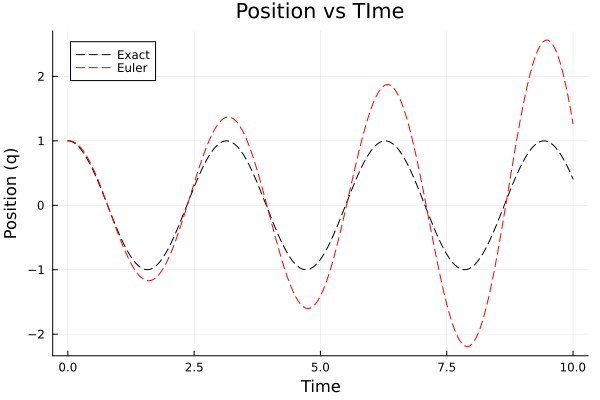

In [4]:
#using HarmonicSolvers
p = SHO_check(1.0,0.0,4.0,0.0,0.0)
u0 = [1.0,0.0]
tspan = (0.0,10.0)
dt = 0.05

prob = MyODEProblem(harmonic_oscillator!, u0, tspan, p)
sol_numerical = integrate(prob, ForwardEuler(), dt=dt)
t_num = sol_numerical.t
q_num = [state[1] for state in sol_numerical.u]
v_num = [state[2] for state in sol_numerical.u]

exact_states = exact_undamped(t_num, u0, p)
q_exact = exact_states[1, :]
v_exact = exact_states[2, :]

E_num = [energy(state,p) for state in sol_numerical.u]
E_exact = fill(energy(u0,p), length(t_num))

p1 = plot(t_num, q_exact, label="Exact", line=:dash, color=:black)
plot!(p1, t_num, q_num, label="Euler", line=:dash, color=:red,title="Position vs TIme",xlabel="Time",ylabel="Position (q)")

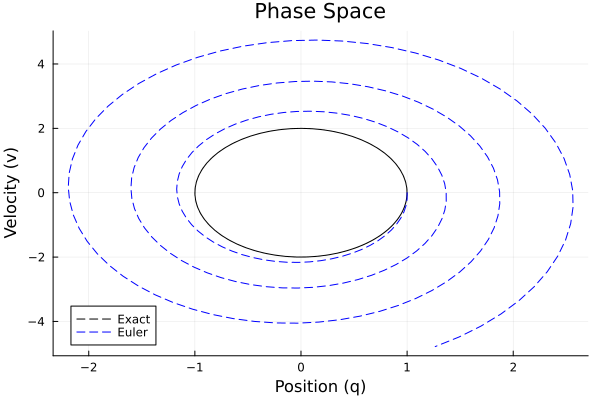

In [5]:
p2 = plot(q_exact, v_exact, label="Exact", line=:dash, color=:black)
plot!(p2, q_num, v_num, label="Euler", line=:dash, color=:blue,title ="Phase Space",xlabel = "Position (q)",ylabel = "Velocity (v)")

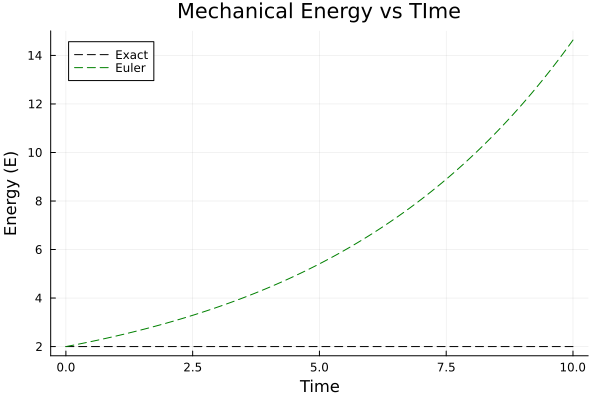

In [6]:
p3 = plot(t_num, E_exact, label="Exact", line=:dash, color=:black)
plot!(p3, t_num, E_num, label="Euler", line=:dash, color=:green, title = "Mechanical Energy vs TIme", xlabel="Time", ylabel = "Energy (E)")

In [7]:
problem = MyODEProblem(harmonic_oscillator!, u0, tspan, p)

euler_solution = integrate(
    problem,
    ForwardEuler();
    dt = 0.05,
)
rk4_solution = integrate(
    problem,
    HarmonicSolvers.RungeKutta4();
    dt = 0.05,
)
symplectic_solution = integrate(
    problem,
    HarmonicSolvers.SymplecticEuler();
    dt = 0.05,
)

ODESolution{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{Float64}}}(0.0:0.05:10.0, [[1.0, 0.0], [0.99, -0.2], [0.9701, -0.398], [0.940499, -0.59202], [0.9014930099999999, -0.7801198], [0.8534720898999999, -0.9604184020000001], [0.7969164489009999, -1.13111281998], [0.7323916434129899, -1.2904961097602001], [0.66054292149085, -1.436974438442798], [0.5820887703538016, -1.569083022740968]  …  [0.9540039106944277, -0.5117300628983632], [0.9188773684425653, -0.7025308450372487], [0.8745620525062772, -0.8863063187257618], [0.8215011160449263, -1.0612187292270172], [0.7602251684231262, -1.2255189524360024], [0.6913469691170948, -1.3775639861206277], [0.6155553001198925, -1.5158333799440467], [0.5336080781214911, -1.638944439968025], [0.446324775341875, -1.7456660555923234], [0.35457822480884005, -1.8349310106606984]])

In [8]:
circle_case = (
    name = "undamped unit circle",
    p = SimpleHarmonicOscillator(
        1.0, # mass
        0.0, # damping
        1.0, # spring constant
        0.0, # drive amplitude
        0.0, # drive frequency
    ),
    u0 = [1.0, 0.0],
    tspan = (0.0, 20π),
    dt = 0.05,
)

(name = "undamped unit circle", p = SimpleHarmonicOscillator(1.0, 0.0, 1.0, 0.0, 0.0), u0 = [1.0, 0.0], tspan = (0.0, 62.83185307179586), dt = 0.05)

In [9]:
shifted_case = (
    name = "constant force and shifted equilibrium",
    p = SimpleHarmonicOscillator(
        1.0,
        0.0,
        1.0,
        1.0,
        0.0,
    ),
    u0 = [0.0, 0.0],
    tspan = (0.0, 10π),
    dt = 0.05,
)

(name = "constant force and shifted equilibrium", p = SimpleHarmonicOscillator(1.0, 0.0, 1.0, 1.0, 0.0), u0 = [0.0, 0.0], tspan = (0.0, 31.41592653589793), dt = 0.05)

In [10]:
damped_case = (
    name = "damped inward spiral",
    p = SimpleHarmonicOscillator(
        1.0,
        0.2,
        1.0,
        0.0,
        0.0,
    ),
    u0 = [1.0, 0.0],
    tspan = (0.0, 30.0),
    dt = 0.05,
)

(name = "damped inward spiral", p = SimpleHarmonicOscillator(1.0, 0.2, 1.0, 0.0, 0.0), u0 = [1.0, 0.0], tspan = (0.0, 30.0), dt = 0.05)

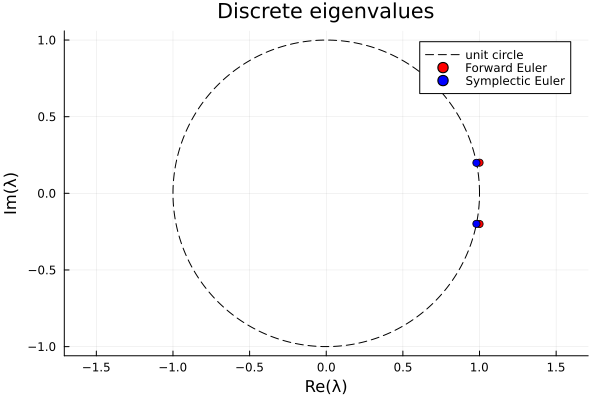

([1.0 0.2; -0.2 1.0], [0.96 0.2; -0.2 1.0], ComplexF64[1.0 - 0.19999999999999998im, 1.0 + 0.19999999999999998im], ComplexF64[0.98 - 0.198997487421324im, 0.98 + 0.198997487421324im])

In [23]:
using LinearAlgebra
using Plots

function matrix_calc(case)
    p = case.p
    h = case.dt * 10
    ω0 = sqrt(p.k / p.m)
    

    A_fe = [1.0 h; -h * ω0^2 1.0]
    A_se = [1.0 - h^2 * ω0^2 h; -h * ω0^2 1.0]

    λ_fe = eigvals(A_fe)
    λ_se = eigvals(A_se)

    θ = range(0, 2π; length = 400)
    fig = Plots.plot(
        cos.(θ),
        sin.(θ),
        label = "unit circle",
        linestyle = :dash,
        color = :black,
        aspect_ratio = :equal,
        xlabel = "Re(λ)",
        ylabel = "Im(λ)",
        title = "Discrete eigenvalues",
    )
    Plots.scatter!(fig, real.(λ_fe), imag.(λ_fe), label = "Forward Euler", color = :red, markersize = 4)
    Plots.scatter!(fig, real.(λ_se), imag.(λ_se), label = "Symplectic Euler", color = :blue, markersize = 4)

    display(fig)
    return A_fe, A_se, λ_fe, λ_se
end

matrix_calc(beating_case)


In [22]:
beating_case = (
    name = "near-resonant beating",
    p = SimpleHarmonicOscillator(
        1.0,
        0.0,
        1.0,
        0.15,
        0.9,
    ),
    u0 = [0.0, 0.0],
    tspan = (0.0, 150.0),
    dt = 0.02,
)

(name = "near-resonant beating", p = SimpleHarmonicOscillator(1.0, 0.0, 1.0, 0.15, 0.9), u0 = [0.0, 0.0], tspan = (0.0, 150.0), dt = 0.02)

In [13]:
resonance_case = (
    name = "damped resonant forcing",
    p = SimpleHarmonicOscillator(
        1.0,
        0.15,
        1.0,
        0.15,
        1.0,
    ),
    u0 = [0.0, 0.0],
    tspan = (0.0, 100.0),
    dt = 0.02,
)

(name = "damped resonant forcing", p = SimpleHarmonicOscillator(1.0, 0.15, 1.0, 0.15, 1.0), u0 = [0.0, 0.0], tspan = (0.0, 100.0), dt = 0.02)

In [14]:
unbounded_resonance_case = (
    name = "undamped exact resonance",
    p = SimpleHarmonicOscillator(
        1.0,
        0.0,
        1.0,
        0.03,
        1.0,
    ),
    u0 = [0.0, 0.0],
    tspan = (0.0, 100.0),
    dt = 0.02,
)

(name = "undamped exact resonance", p = SimpleHarmonicOscillator(1.0, 0.0, 1.0, 0.03, 1.0), u0 = [0.0, 0.0], tspan = (0.0, 100.0), dt = 0.02)

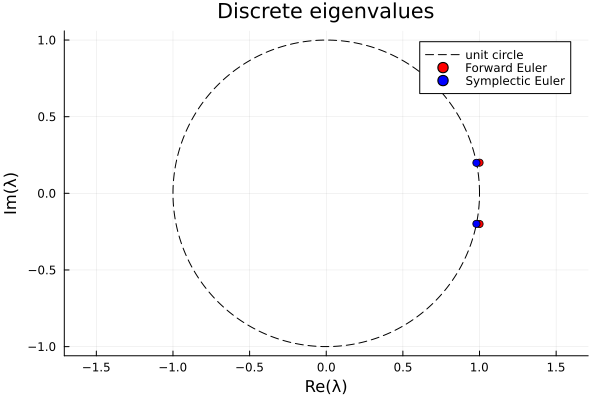

([1.0 0.2; -0.2 1.0], [0.96 0.2; -0.2 1.0], ComplexF64[1.0 - 0.19999999999999998im, 1.0 + 0.19999999999999998im], ComplexF64[0.98 - 0.198997487421324im, 0.98 + 0.198997487421324im])

In [15]:
matrix_calc(unbounded_resonance_case)

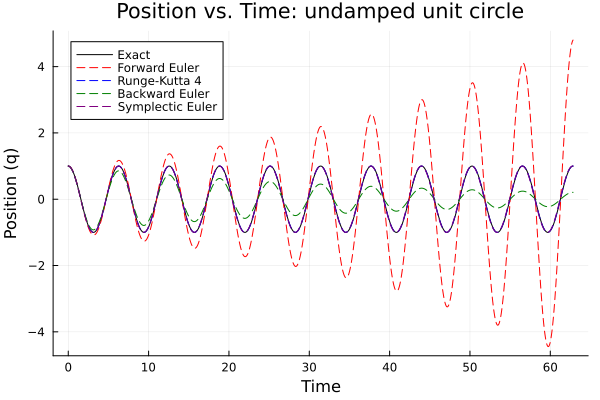

In [16]:

function plot_case(case)
    p = case.p
    u0 = case.u0
    tspan = case.tspan
    dt = case.dt

    prob = MyODEProblem(harmonic_oscillator!, u0, tspan, p)

    sol_forward = integrate(prob, ForwardEuler(); dt = dt)
    sol_rk4 = integrate(prob, RungeKutta4(); dt = dt)
    sol_backward = integrate(prob, BackwardEuler(); dt = dt)
    sol_symplectic = integrate(prob, SymplecticEuler(); dt = dt)

    t_num = sol_forward.t
    q_exact = exact_undamped(t_num, u0, p)[1, :]
    q_forward = [state[1] for state in sol_forward.u]
    q_rk4 = [state[1] for state in sol_rk4.u]
    q_backward = [state[1] for state in sol_backward.u]
    q_symplectic = [state[1] for state in sol_symplectic.u]

    exact_plot = plot(
        t_num,
        q_exact,
        label = "Exact",
        line = :solid,
        color = :black,
        xlabel = "Time",
        ylabel = "Position (q)",
        title = "Position vs. Time: $(case.name)",
    )
    plot!(exact_plot, t_num, q_forward, label = "Forward Euler", line = :dash, color = :red)
    plot!(exact_plot, t_num, q_rk4, label = "Runge-Kutta 4", line = :dash, color = :blue)
    plot!(exact_plot, t_num, q_backward, label = "Backward Euler", line = :dash, color = :green)
    plot!(exact_plot, t_num, q_symplectic, label = "Symplectic Euler", line = :dash, color = :purple)

    display(exact_plot)
    #return exact_plot
end

plot_case(circle_case)

# Future Projects

In [17]:
using BenchmarkTools

p = SimpleHarmonicOscillator(1.0,0.1,2.0,1.0,0.5)
x = [1.0,0.0]
dx = similar(x)

println("Out of Place")
@btime harmonic_oscillator($x,$p,0.0) #creates and returns a new vector array on every timestep 

println("Direct indexing")

@btime harmonic_oscillator_free!($dx,$x,$p,0.0) #modifies exisiting vecotr in memorty

Out of Place
  72.649 ns (10 allocations: 432 bytes)
Direct indexing
  5.208 ns (0 allocations: 0 bytes)


In [18]:
p_unstable = UnstableOscillator(1.0,0.1,2.0,1.0,0.5)

println("Stable Parameter Performance:")
@btime harmonic_oscillator_free!($dx,$x,$p,0.0)

println("Unstable 'Any' Parameter Performance")

@btime harmonic_oscillator_free!($dx,$x,$p_unstable,0.0)


Stable Parameter Performance:
  5.166 ns (0 allocations: 0 bytes)
Unstable 'Any' Parameter Performance
  125.418 ns (13 allocations: 208 bytes)


In [19]:
#Experimentally find the largest stable step size for symplectic Euler. Express your answer
#using the dimensionless quantity hω
#tr(M) = 2-(omega*dt)^2 qn+1;vn+1 = M qn;vn

function is_stable(problem,solver,dt; threshold=10.0)
    sol = integrate(problem,solver;dt=dt)
    initial_amplitude = norm(problem.u0)

    for state in sol.u
        if any(isnan, state) || any(isinf,state) || norm(state) > threshold * initial_amplitude
            return false
        end
    end
    return true
end

function find_crit_dt(problem, solver; dt_min=0.01, dt_max=5.0, tolerance=1e-5)
    low = dt_min
    high = dt_max
    if !is_stable(problem,solver,low)
        error("THe lower bound is already unstable decrease dt_min")
    end
    if is_stable(problem,solver,high)
        error("The upper bound is still stable increase dt_max")
    end

    while (high-low) > tolerance
        mid = (low+high)/2
        if is_stable(problem,solver,mid)
            low = mid
        else
            high = mid
        end
    end
    return (low+high)/2
end




find_crit_dt (generic function with 1 method)

In [21]:
const ω = 1.0

params = SHO_check(1.0,0.0,4.0,0.0,ω)

tspan = (0.0,100.0)
u0 = [1.0,  0.0]
prob = MyODEProblem(harmonic_oscillator!, u0, tspan, params)

solver = HarmonicSolvers.SymplecticEuler()
h_crit = find_crit_dt(prob,solver)

dimensionless_limit = h_crit * ω

println("Experimental Critical Step Size:", round(h_crit,digits=5))
println("Experiment Dimensionless Limit", round(dimensionless_limit, digits=5))

Experimental Critical Step Size:0.97512
Experiment Dimensionless Limit0.97512
